# **Task 2** - Experimentation and uplife testing
As I am new to a lot tools and directions that I have not encounted before, I decided to follow closely the draft solutions document

In [145]:
# Import libraries
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np

In [146]:
# Read files
data = pd.read_csv("QVI_data.csv")

## **1) Dataset Previews**

In [147]:
# transactionData file preview
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [148]:
# Check for the number of stores in the dataset
data['STORE_NBR'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86, 155,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

There are 272 stores in this dataset. For this analysis, we have 3 trial stores and the the others 3 correspondent control stores that we have tasked to find.

In [149]:
data.describe()

,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648340e+05,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,135.079423,1.351576e+05,56.583554,1.905813,7.299346,182.425512
std,8.057990e+04,76.784063,7.813292e+04,32.826444,0.343436,2.527241,64.325148
min,1.000000e+03,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,70.000000,6.760050e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,130.000000,1.351365e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,203.000000,2.026998e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000


In [150]:
# Check for null
data.isnull().sum()

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

## **2) Data Cleaning**

In [151]:
# Convert YEARMONTH data type to integer
data['YEARMONTH'] = pd.to_datetime(data['DATE']).dt.strftime('%Y%m').astype(int)
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,201810
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,201809
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,201903
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,201903
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,201811


**measures_over_time** - A table is created to include other features we needed for further analysis.

In [152]:
# Create a table named measure_over_time
measure_over_time = data.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    totSales=('TOT_SALES', 'sum'),
    nCustomers=('LYLTY_CARD_NBR', pd.Series.nunique),
    nTxn=('TXN_ID', 'count'),
    nChips=('PROD_NAME', lambda x: (x.str.contains("Chips", case=False)).sum())
).reset_index()

measure_over_time['nTxnPerCust'] = measure_over_time['nTxn'] / measure_over_time['nCustomers']
measure_over_time['nChipsPerTxn'] = measure_over_time['nChips'] / measure_over_time['nTxn']
measure_over_time['avgPricePerUnit'] = measure_over_time['totSales'] / measure_over_time['nChips']

measure_over_time

,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxn,nChips,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,13,1.061224,0.250000,15.915385
1,1,201808,176.1,42,43,7,1.023810,0.162791,25.157143
2,1,201809,278.8,59,62,16,1.050847,0.258065,17.425000
3,1,201810,188.1,44,45,9,1.022727,0.200000,20.900000
4,1,201811,192.6,46,47,12,1.021739,0.255319,16.050000
...,...,...,...,...,...,...,...,...,...
3164,272,201902,395.5,45,48,11,1.066667,0.229167,35.954545
3165,272,201903,442.3,50,53,10,1.060000,0.188679,44.230000
3166,272,201904,445.1,54,56,14,1.037037,0.250000,31.792857
3167,272,201905,314.6,34,40,7,1.176471,0.175000,44.942857


In [153]:
# A table stores data before trial preiod
store_month_counts = measure_over_time.groupby('STORE_NBR')['YEARMONTH'].nunique().reset_index()

store_full_obvs = store_month_counts[store_month_counts['YEARMONTH'] == 12]['STORE_NBR']

pre_trial = measure_over_time[
    (measure_over_time['YEARMONTH'] < 201902) &
    (measure_over_time['STORE_NBR'].isin(store_full_obvs))
]

In [154]:
# Create a function for calculating the correlation
def cal_correlation(input_table, metric_col, trial_store):
    correlations = []
    
    trial_data = input_table[input_table['STORE_NBR'] == trial_store]
    store_number = input_table['STORE_NBR'].unique()
    
    for store in store_number:
        if store == trial_store: continue
        
        compare_data = input_table[input_table['STORE_NBR'] == store]
        
        merged = pd.merge(trial_data[['YEARMONTH', metric_col]],
                          compare_data[['YEARMONTH', metric_col]],
                          on='YEARMONTH',
                          suffixes=('_trial', '_control')
                          )
        
        corr = merged[f'{metric_col}_trial'].corr(merged[f'{metric_col}_control'])
        
        correlations.append({'Store1': trial_store, 'Store2': store, 'corr_measure': corr})

    return pd.DataFrame(correlations)

In [155]:
# Create a function for calculating magnitude distance
def cal_magnitude_dist(input_table, metric_col, trial_store):
    distance = pd.DataFrame(columns=['Store1', 'Store2', 'YEARMONTH', 'measure'])
    store_number = input_table['STORE_NBR'].unique()

    trial_data = input_table[input_table['STORE_NBR'] == trial_store]

    for store in store_number:
        if store == trial_store: continue
        
        compare_data = input_table[input_table['STORE_NBR'] == store]

        merged = pd.merge(trial_data[['YEARMONTH', metric_col]],
                          compare_data[['YEARMONTH', metric_col]],
                          on='YEARMONTH',
                          suffixes=('_trial', '_control')
                          )

        merged['measure'] = np.abs(merged[f'{metric_col}_trial'] - merged[f'{metric_col}_control'])

        merged['Store1'] = trial_store
        merged['Store2'] = store

        distance = pd.concat([distance, merged[['Store1','Store2','YEARMONTH','measure']]])
        
    distance['min_measure'] = distance.groupby(['Store1', 'YEARMONTH'])['measure'].transform('min')
    distance['max_measure'] = distance.groupby(['Store1', 'YEARMONTH'])['measure'].transform('max')
    
    distance['mag_measure'] = 1 - (distance['measure'] - distance['min_measure']) / \
                                            (distance['max_measure'] - distance['min_measure'])
    
    final_scores = distance.groupby(['Store1', 'Store2'])['mag_measure'].mean().reset_index()
    final_scores.columns = ['Store1', 'Store2', 'mag_measure']
    
    return final_scores
    

**cal_correlation & cal_magnitude_dist** - calculate the correlation and the magnitude distance between stores. We use this function to find the similar stores for the trial stores

## **3) Store Analysis**

### 3.1. Store 77

In [156]:
trial_store = 77

corr_sales = cal_correlation(pre_trial, 'totSales', trial_store)
corr_customers = cal_correlation(pre_trial, 'nCustomers', trial_store)

mag_sales = cal_magnitude_dist(pre_trial, 'totSales', trial_store)
mag_customers = cal_magnitude_dist(pre_trial, 'nCustomers', trial_store)

C:\Users\daoth\AppData\Local\Temp\ipykernel_15296\601032495.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  distance = pd.concat([distance, merged[['Store1','Store2','YEARMONTH','measure']]])


In [157]:
# Using correlation weights to find correlated stores
corr_weight = 0.5
score_sales = pd.merge(corr_sales,
                mag_sales,
                on=['Store1', 'Store2'])

score_sales['scoreSales'] = (score_sales['corr_measure'] * corr_weight +
                             score_sales['mag_measure'] * (1 - corr_weight))

score_customer = pd.merge(corr_customers,
                mag_customers,
                on=['Store1', 'Store2'])

score_customer['scoreCustomer'] = (score_customer['corr_measure'] * corr_weight +
                             score_customer['mag_measure'] * (1 - corr_weight))

In [158]:
# Score control table
score_control = pd.merge(score_sales,
                score_customer,
                on=['Store1', 'Store2'])
score_control

,Store1,Store2,corr_measure_x,mag_measure_x,scoreSales,corr_measure_y,mag_measure_y,scoreCustomer
0,77,1,0.075218,0.955061,0.515139,0.322168,0.940321,0.631244
1,77,2,-0.263079,0.939318,0.338120,-0.572051,0.924638,0.176294
2,77,3,0.806644,0.354963,0.580803,0.834207,0.345067,0.589637
3,77,4,-0.263300,0.177414,-0.042943,-0.295639,0.189579,-0.05303
4,77,5,-0.110652,0.554066,0.221707,0.370659,0.481199,0.425929
...,...,...,...,...,...,...,...,...
254,77,268,0.344757,0.962563,0.653660,0.369517,0.939907,0.654712
255,77,269,-0.315730,0.452903,0.068586,-0.474293,0.343547,-0.065373
256,77,270,0.315430,0.446991,0.381211,-0.131259,0.357725,0.113233
257,77,271,0.355487,0.553304,0.454396,0.019629,0.483457,0.251543


In [159]:
score_control = pd.merge(score_sales,
                score_customer,
                on=['Store1', 'Store2'])

score_control['finalControlScore'] = (score_control['scoreSales'] + score_control['scoreCustomer']) * 0.5

In [160]:
control_store = score_control[score_control['Store1'] == trial_store].sort_values(by='finalControlScore', ascending=False).iloc[0]['Store2']
control_store

233

So the most similar store to 77 is 233.

#### 3.1.1. Graphs for total Sales and Number of Customers before trial - *Store 77*

In [161]:
# Create a feature to differenate store types
pre_trial['STORE_TYPE'] = pre_trial['STORE_NBR'].apply(
    lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
)

store_types = pre_trial['STORE_TYPE'].unique()

C:\Users\daoth\AppData\Local\Temp\ipykernel_15296\3911875792.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_trial['STORE_TYPE'] = pre_trial['STORE_NBR'].apply(


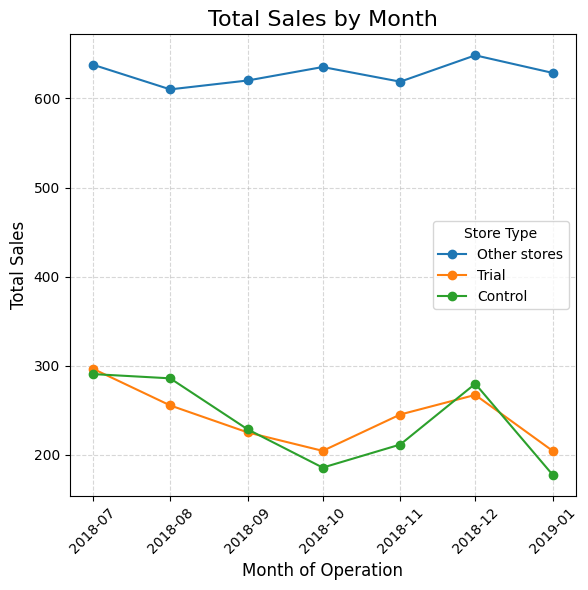

In [162]:
# Trends based on driver during the period before trial (Sales)
past_sales_trial = pre_trial.groupby(['YEARMONTH', 'STORE_TYPE'])['totSales'].mean().reset_index()

past_sales_trial['TransactionMonth'] = pd.to_datetime(
    (past_sales_trial['YEARMONTH'] // 100).astype(str) + "-" + (past_sales_trial['YEARMONTH'] % 100).astype(str),
    format="%Y-%m"
)

plt.figure(figsize=(6, 6))

for store_type in store_types:
    temp_data = past_sales_trial[past_sales_trial['STORE_TYPE'] == store_type]
    plt.plot(
        temp_data['TransactionMonth'],
        temp_data['totSales'],
        marker='o',
        label=store_type
    )

plt.title("Total Sales by Month", fontsize=16)
plt.xlabel("Month of Operation", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.legend(title="Store Type")
plt.xticks(rotation=45)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


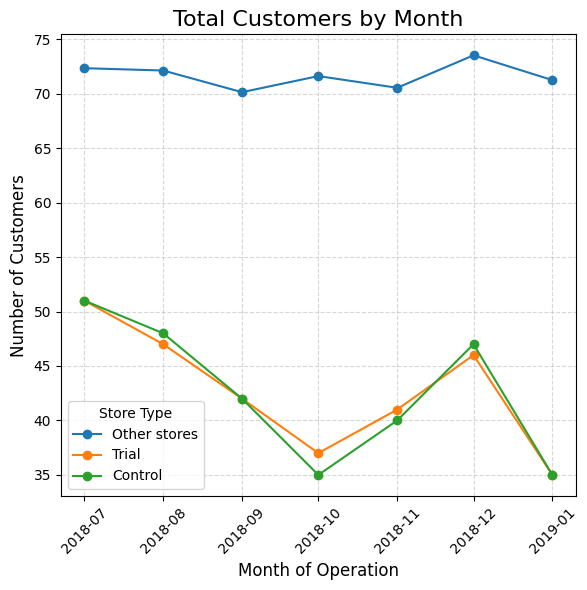

In [163]:
# Trends based on driver during the period before trial (Customer)
past_customers = pre_trial.groupby(['YEARMONTH', 'STORE_TYPE'])['nCustomers'].mean().reset_index()

past_customers['TransactionMonth'] = pd.to_datetime(
    (past_customers['YEARMONTH'] // 100).astype(str) + "-" + (past_customers['YEARMONTH'] % 100).astype(str),
    format="%Y-%m"
)

plt.figure(figsize=(6, 6))

for store_type in store_types:
    temp_data = past_customers[past_customers['STORE_TYPE'] == store_type]
    plt.plot(
        temp_data['TransactionMonth'],
        temp_data['nCustomers'],
        marker='o',
        label=store_type
    )

plt.title("Total Customers by Month", fontsize=16)
plt.xlabel("Month of Operation", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title="Store Type")
plt.xticks(rotation=45)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

#### 3.1.2. Assessment of Trial - *Store 77*

##### a. Scaled Sales

In [164]:
# Scaling sales pre trial stores (77 & 233)
scaling_factor_sales = pre_trial[pre_trial['STORE_NBR'] == trial_store]['totSales'].sum() / pre_trial[pre_trial['STORE_NBR'] == control_store]['totSales'].sum()
scaling_factor_sales

sales_over_time = measure_over_time.copy()

sales_over_time['scaledControlSales'] = sales_over_time.apply(
    lambda row: row['totSales'] * scaling_factor_sales 
    if row['STORE_NBR'] == control_store else np.nan,
    axis=1)

In [165]:
# Apply scaling factor
scaled_control_sales = sales_over_time[
    sales_over_time['STORE_NBR'] == control_store][['YEARMONTH', 'scaledControlSales']]

trial_store_sales = sales_over_time[
    sales_over_time['STORE_NBR'] == trial_store][['YEARMONTH', 'totSales']]

percent_diff_sales = pd.merge(scaled_control_sales,
                trial_store_sales,
                on=['YEARMONTH'])
percent_diff_sales['percentDiff'] = np.abs(percent_diff_sales['scaledControlSales'] - percent_diff_sales['totSales']) / percent_diff_sales['scaledControlSales']
percent_diff_sales

,YEARMONTH,scaledControlSales,totSales,percentDiff
0,201807,297.565550,296.8,0.002573
1,201808,292.652187,255.5,0.126950
2,201809,233.998916,225.2,0.037602
3,201810,190.085733,204.5,0.075830
4,201811,216.597421,245.3,0.132516
5,201812,286.408121,267.3,0.066716
6,201901,181.692071,204.4,0.124980
7,201902,249.762622,235.0,0.059107
8,201903,203.802205,278.5,0.366521
9,201904,162.345704,263.5,0.623080


In [166]:
# Calculate the percentage difference between scaled control and trial sales
pretrial_percent_diff_S = percent_diff_sales[percent_diff_sales['YEARMONTH'] < 201902]
std_dev_s = np.std(pretrial_percent_diff_S['percentDiff'])

degree_of_freedom = 7

In [167]:
# Change date format
percent_diff_sales['TransactionMonth'] = pd.to_datetime(
    (percent_diff_sales['YEARMONTH'] // 100).astype(str) + "-" + (percent_diff_sales['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

In [168]:
# Create a table for data during trial period
trial_data = percent_diff_sales[
    (percent_diff_sales['YEARMONTH'] > 201901) &
    (percent_diff_sales['YEARMONTH'] < 201905)].copy()

trial_data['tValue'] = (trial_data['percentDiff'] - 0)/ std_dev_s
trial_data

,YEARMONTH,scaledControlSales,totSales,percentDiff,TransactionMonth,tValue
7,201902,249.762622,235.0,0.059107,2019-02-01,1.278363
8,201903,203.802205,278.5,0.366521,2019-03-01,7.927151
9,201904,162.345704,263.5,0.623080,2019-04-01,13.476023


We will test null hypothesis between trial and control store.

In [169]:
# 95th percentile of the t distribution
from scipy import stats as st

t_dist_s = st.t.ppf(0.95, degree_of_freedom)
t_dist_s


1.894578605061305

In [170]:
# Create a table for the total sales of trial and control store
past_sales = measure_over_time.copy()
past_sales['STORE_TYPE'] = past_sales['STORE_NBR'].apply(
    lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
)
past_sales = past_sales.groupby(['YEARMONTH', 'STORE_TYPE'])['totSales'].mean().reset_index()

past_sales['TransactionMonth'] = pd.to_datetime(
    (past_sales['YEARMONTH'] // 100).astype(str) + "-" + (past_sales['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

In [171]:
# Control store 95th percentile
past_sales_control_95 = past_sales[past_sales['STORE_TYPE'] == 'Control'].copy()
past_sales_control_95['totSales'] = past_sales_control_95['totSales'] * (1 + std_dev_s * 2)
past_sales_control_95['STORE_TYPE'] = 'Control 95th % confidence interval'

# Control store 5th percentile
past_sales_control_5 = past_sales[past_sales['STORE_TYPE'] == 'Control'].copy()
past_sales_control_5['totSales'] = past_sales_control_5['totSales'] * (1 - std_dev_s * 2)
past_sales_control_5['STORE_TYPE'] = 'Control 5th % confidence interval'

# Contains both percentiles
trial_assessment = pd.concat([
    past_sales,
    past_sales_control_95,
    past_sales_control_5
])

In [172]:
#Number of unique store types
store_types = trial_assessment[trial_assessment['STORE_TYPE'] != 'Other stores']['STORE_TYPE'].unique()

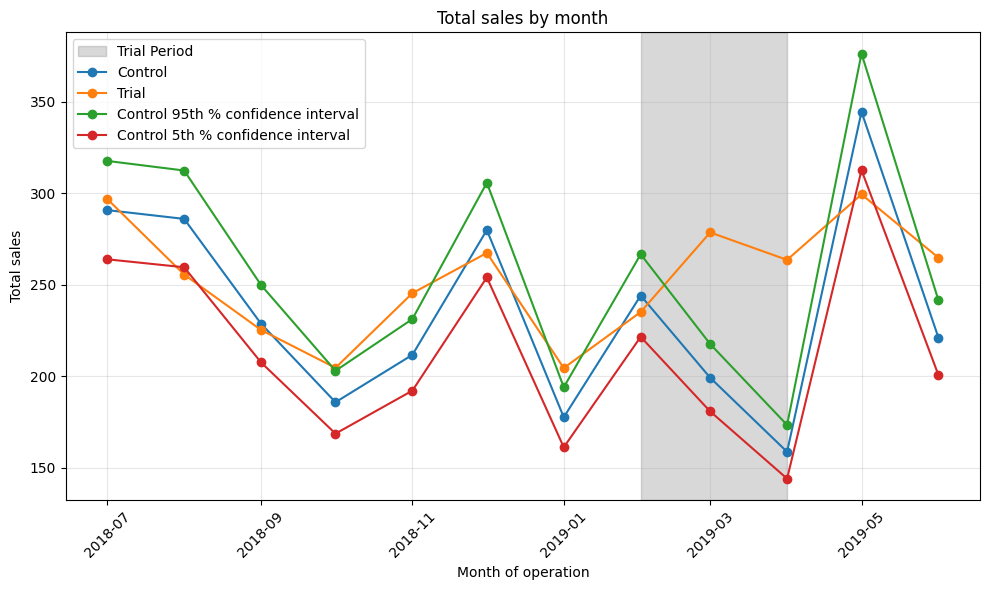

In [173]:
# Plot a graph showcasing these store types (Sales)
plt.figure(figsize=(10,6))

plt.axvspan(
    pd.to_datetime('2019-02-01'),
    pd.to_datetime('2019-04-01'),
    color='grey',
    alpha=0.3,  
    label='Trial Period'
)

for store_type in store_types:
    data = trial_assessment[trial_assessment['STORE_TYPE'] == store_type]
    plt.plot(
        data['TransactionMonth'],
        data['totSales'],
        label=store_type,
        marker='o'
    )

plt.title('Total sales by month')
plt.xlabel('Month of operation')
plt.ylabel('Total sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Significant difference in total sales in the control and the trial store during the trial period

##### b. Scaled Customers

In [174]:
# Scaling no of customer pre trial stores (77 & 233)
scaling_factor_customer = pre_trial[pre_trial['STORE_NBR'] == trial_store]['totSales'].sum() / pre_trial[pre_trial['STORE_NBR'] == control_store]['totSales'].sum()
scaling_factor_customer

customers_over_time = measure_over_time.copy()

customers_over_time['scaledControlCustomers'] = customers_over_time.apply(
    lambda row: row['nCustomers'] * scaling_factor_customer 
    if row['STORE_NBR'] == control_store else np.nan,
    axis=1)

In [175]:
scaled_control_customers = customers_over_time[
    customers_over_time['STORE_NBR'] == control_store][['YEARMONTH', 'scaledControlCustomers']]

trial_store_customers = customers_over_time[
    customers_over_time['STORE_NBR'] == trial_store][['YEARMONTH', 'nCustomers']]

percent_diff_cus = pd.merge(scaled_control_customers,
                trial_store_customers,
                on=['YEARMONTH'])
percent_diff_cus['percentDiff'] = np.abs(percent_diff_cus['scaledControlCustomers'] - percent_diff_cus['nCustomers']) / percent_diff_cus['scaledControlCustomers']
percent_diff_cus

,YEARMONTH,scaledControlCustomers,nCustomers,percentDiff
0,201807,52.204482,51,0.023072
1,201808,49.133631,47,0.043425
2,201809,42.991927,42,0.023072
3,201810,35.826606,37,0.032752
4,201811,40.944692,41,0.001351
5,201812,48.110013,46,0.043858
6,201901,35.826606,35,0.023072
7,201902,46.062779,45,0.023072
8,201903,40.944692,50,0.221160
9,201904,30.708519,47,0.530520


In [176]:
# Calculate the percentage difference between scaled control and trial sales
pretrial_percent_diff_C = percent_diff_cus[percent_diff_cus['YEARMONTH'] < 201902]
std_dev_c = np.std(pretrial_percent_diff_C['percentDiff'])

degree_of_freedom = 7

# Change date format
percent_diff_cus['TransactionMonth'] = pd.to_datetime(
    (percent_diff_cus['YEARMONTH'] // 100).astype(str) + "-" + (percent_diff_cus['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

In [177]:
# Create a table for data during trial period
trial_data_customers = percent_diff_cus[
    (percent_diff_cus['YEARMONTH'] > 201901) &
    (percent_diff_cus['YEARMONTH'] < 201905)].copy()

trial_data_customers['tValue'] = (trial_data_customers['percentDiff'] - 0)/ std_dev_c
trial_data_customers

,YEARMONTH,scaledControlCustomers,nCustomers,percentDiff,TransactionMonth,tValue
7,201902,46.062779,45,0.023072,2019-02-01,1.699037
8,201903,40.944692,50,0.221160,2019-03-01,16.286047
9,201904,30.708519,47,0.530520,2019-04-01,39.067152


In [178]:
# Create a table for the total sales of trial and control store
past_customers = measure_over_time.copy()
past_customers['STORE_TYPE'] = past_customers['STORE_NBR'].apply(
    lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
)
past_customers = past_customers.groupby(['YEARMONTH', 'STORE_TYPE'])['nCustomers'].mean().reset_index()

past_customers['TransactionMonth'] = pd.to_datetime(
    (past_customers['YEARMONTH'] // 100).astype(str) + "-" + (past_customers['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

# Control store 95th percentile
past_customers_control_95 = past_customers[past_customers['STORE_TYPE'] == 'Control'].copy()
past_customers_control_95['nCustomers'] = past_customers_control_95['nCustomers'] * (1 + std_dev_c * 2)
past_customers_control_95['STORE_TYPE'] = 'Control 95th % confidence interval'

# Control store 5th percentile
past_customers_control_5 = past_customers[past_customers['STORE_TYPE'] == 'Control'].copy()
past_customers_control_5['nCustomers'] = past_customers_control_5['nCustomers'] * (1 - std_dev_c * 2)
past_customers_control_5['STORE_TYPE'] = 'Control 5th % confidence interval'

# Contains both percentiles
trial_assessment_cus = pd.concat([
    past_customers,
    past_customers_control_95,
    past_customers_control_5
])

#Number of unique store types
store_types = trial_assessment_cus[trial_assessment_cus['STORE_TYPE'] != 'Other stores']['STORE_TYPE'].unique()

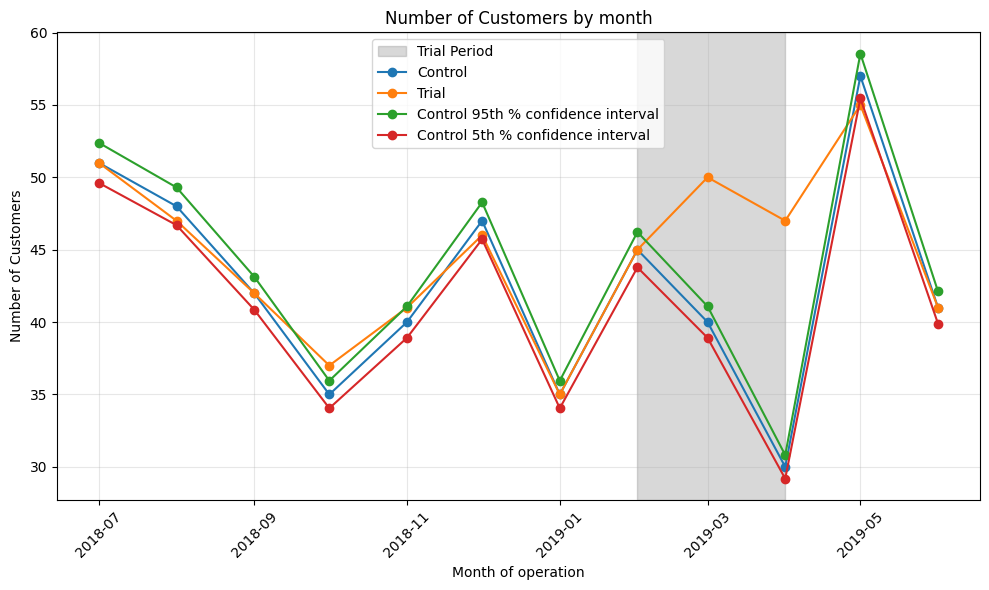

In [179]:
# Plot a graph showcasing these store types (Customers)
plt.figure(figsize=(10,6))

plt.axvspan(
    pd.to_datetime('2019-02-01'),
    pd.to_datetime('2019-04-01'),
    color='grey',
    alpha=0.3,  
    label='Trial Period'
)

for store_type in store_types:
    data = trial_assessment_cus[trial_assessment_cus['STORE_TYPE'] == store_type]
    plt.plot(
        data['TransactionMonth'],
        data['nCustomers'],
        label=store_type,
        marker='o'
    )

plt.title('Number of Customers by month')
plt.xlabel('Month of operation')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Significant difference in number of customers in the control and the trial store during the trial period

### 3.2. Store 86

In [180]:
trial_store = 86

corr_sales = cal_correlation(pre_trial, 'totSales', trial_store)
corr_customers = cal_correlation(pre_trial, 'nCustomers', trial_store)

mag_sales = cal_magnitude_dist(pre_trial, 'totSales', trial_store)
mag_customers = cal_magnitude_dist(pre_trial, 'nCustomers', trial_store)

C:\Users\daoth\AppData\Local\Temp\ipykernel_15296\601032495.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  distance = pd.concat([distance, merged[['Store1','Store2','YEARMONTH','measure']]])


In [181]:
# Using correlation weights to find correlated stores
corr_weight = 0.5
score_sales = pd.merge(corr_sales,
                mag_sales,
                on=['Store1', 'Store2'])

score_sales['scoreSales'] = (score_sales['corr_measure'] * corr_weight +
                             score_sales['mag_measure'] * (1 - corr_weight))

score_customer = pd.merge(corr_customers,
                mag_customers,
                on=['Store1', 'Store2'])

score_customer['scoreCustomer'] = (score_customer['corr_measure'] * corr_weight +
                             score_customer['mag_measure'] * (1 - corr_weight))

score_control = pd.merge(score_sales,
                score_customer,
                on=['Store1', 'Store2'])
score_control

,Store1,Store2,corr_measure_x,mag_measure_x,scoreSales,corr_measure_y,mag_measure_y,scoreCustomer
0,86,1,0.445632,0.220565,0.333099,0.485831,0.444597,0.465214
1,86,2,-0.403835,0.179640,-0.112097,-0.086161,0.38062,0.14723
2,86,3,-0.261284,0.762894,0.250805,-0.353786,0.91185,0.279032
3,86,4,-0.039035,0.498526,0.229745,-0.169608,0.773922,0.302157
4,86,5,0.235159,0.929321,0.582240,-0.253229,0.926509,0.33664
...,...,...,...,...,...,...,...,...
254,86,268,-0.452182,0.250819,-0.100681,-0.034273,0.42739,0.196558
255,86,269,0.697055,0.902040,0.799548,-0.098587,0.917082,0.409248
256,86,270,-0.730679,0.834520,0.051921,-0.767267,0.890489,0.061611
257,86,271,0.527637,0.922919,0.725278,0.267393,0.935896,0.601644


In [182]:
# Score control table
score_control = pd.merge(score_sales,
                score_customer,
                on=['Store1', 'Store2'])

score_control['finalControlScore'] = (score_control['scoreSales'] + score_control['scoreCustomer']) * 0.5

control_store = score_control[score_control['Store1'] == trial_store].sort_values(by='finalControlScore', ascending=False).iloc[0]['Store2']
control_store

155

So the most similar store to 86 is 155.

#### 3.2.1. Graphs for total Sales and Number of Customers before trial - *Store 86*

In [183]:
# Create a feature to differenate store types
pre_trial['STORE_TYPE'] = pre_trial['STORE_NBR'].apply(
    lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
)

store_types = pre_trial['STORE_TYPE'].unique()

C:\Users\daoth\AppData\Local\Temp\ipykernel_15296\3911875792.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_trial['STORE_TYPE'] = pre_trial['STORE_NBR'].apply(


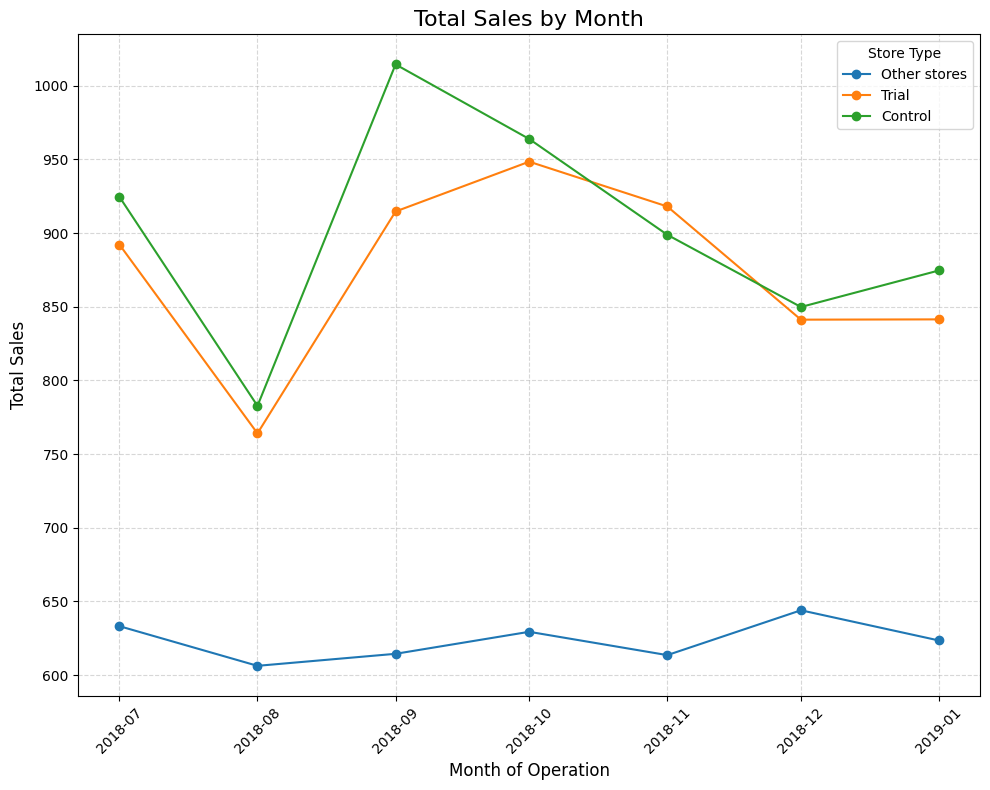

In [184]:
# Trends based on driver during the period before trial (Sales)
past_sales_trial = pre_trial.groupby(['YEARMONTH', 'STORE_TYPE'])['totSales'].mean().reset_index()

past_sales_trial['TransactionMonth'] = pd.to_datetime(
    (past_sales_trial['YEARMONTH'] // 100).astype(str) + "-" + (past_sales_trial['YEARMONTH'] % 100).astype(str),
    format="%Y-%m"
)

plt.figure(figsize=(10, 8))

for store_type in store_types:
    temp_data = past_sales_trial[past_sales_trial['STORE_TYPE'] == store_type]
    plt.plot(
        temp_data['TransactionMonth'],
        temp_data['totSales'],
        marker='o',
        label=store_type
    )

plt.title("Total Sales by Month", fontsize=16)
plt.xlabel("Month of Operation", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.legend(title="Store Type")
plt.xticks(rotation=45)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

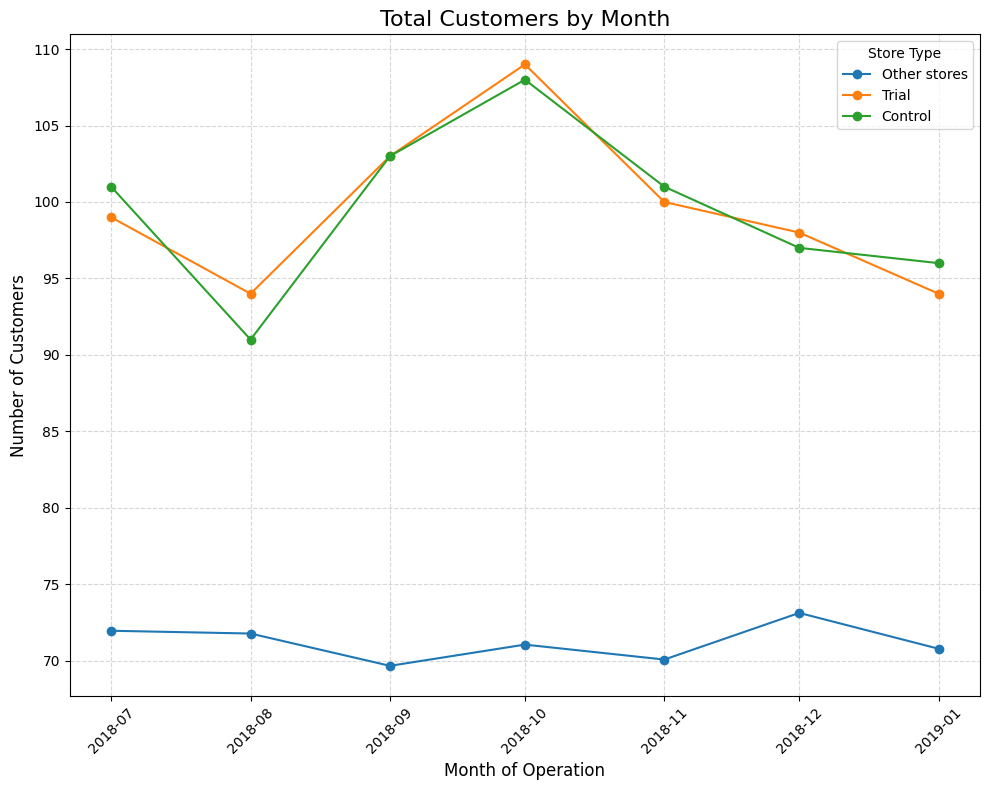

In [185]:
# Trends based on driver during the period before trial (Customer)
past_customers = pre_trial.groupby(['YEARMONTH', 'STORE_TYPE'])['nCustomers'].mean().reset_index()

past_customers['TransactionMonth'] = pd.to_datetime(
    (past_customers['YEARMONTH'] // 100).astype(str) + "-" + (past_customers['YEARMONTH'] % 100).astype(str),
    format="%Y-%m"
)

plt.figure(figsize=(10, 8))

for store_type in store_types:
    temp_data = past_customers[past_customers['STORE_TYPE'] == store_type]
    plt.plot(
        temp_data['TransactionMonth'],
        temp_data['nCustomers'],
        marker='o',
        label=store_type
    )

plt.title("Total Customers by Month", fontsize=16)
plt.xlabel("Month of Operation", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title="Store Type")
plt.xticks(rotation=45)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

#### 3.2.2. Assessment of Trial - *Store 86*

##### a. Scaled Sales

In [186]:
# Scaling sales pre trial stores (86 & 155)
scaling_factor_sales = pre_trial[pre_trial['STORE_NBR'] == trial_store]['totSales'].sum() / pre_trial[pre_trial['STORE_NBR'] == control_store]['totSales'].sum()
scaling_factor_sales

sales_over_time = measure_over_time.copy()

sales_over_time['scaledControlSales'] = sales_over_time.apply(
    lambda row: row['totSales'] * scaling_factor_sales 
    if row['STORE_NBR'] == control_store else np.nan,
    axis=1)

In [187]:
# Apply scaling factor
scaled_control_sales = sales_over_time[
    sales_over_time['STORE_NBR'] == control_store][['YEARMONTH', 'scaledControlSales']]

trial_store_sales = sales_over_time[
    sales_over_time['STORE_NBR'] == trial_store][['YEARMONTH', 'totSales']]

percent_diff_sales = pd.merge(scaled_control_sales,
                trial_store_sales,
                on=['YEARMONTH'])
percent_diff_sales['percentDiff'] = np.abs(percent_diff_sales['scaledControlSales'] - percent_diff_sales['totSales']) / percent_diff_sales['scaledControlSales']
percent_diff_sales

,YEARMONTH,scaledControlSales,totSales,percentDiff
0,201807,896.922236,892.20,0.005265
1,201808,759.269991,764.05,0.006296
2,201809,984.034086,914.60,0.070561
3,201810,934.948790,948.40,0.014387
4,201811,871.894555,918.00,0.052880
5,201812,824.361363,841.20,0.020426
6,201901,848.418979,841.40,0.008273
7,201902,864.522060,913.20,0.056306
8,201903,780.320405,1026.80,0.315870
9,201904,819.317024,848.20,0.035253


In [188]:
# Calculate the percentage difference between scaled control and trial sales
pretrial_percent_diff_S = percent_diff_sales[percent_diff_sales['YEARMONTH'] < 201902]
std_dev_s = np.std(pretrial_percent_diff_S['percentDiff'])

degree_of_freedom = 7

# Change date format
percent_diff_sales['TransactionMonth'] = pd.to_datetime(
    (percent_diff_sales['YEARMONTH'] // 100).astype(str) + "-" + (percent_diff_sales['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

# Create a table for data during trial period
trial_data = percent_diff_sales[
    (percent_diff_sales['YEARMONTH'] > 201901) &
    (percent_diff_sales['YEARMONTH'] < 201905)].copy()

trial_data['tValue'] = (trial_data['percentDiff'] - 0)/ std_dev_s
trial_data

,YEARMONTH,scaledControlSales,totSales,percentDiff,TransactionMonth,tValue
7,201902,864.522060,913.2,0.056306,2019-02-01,2.354174
8,201903,780.320405,1026.8,0.315870,2019-03-01,13.206585
9,201904,819.317024,848.2,0.035253,2019-04-01,1.473915


In [189]:
# Create a table for the total sales of trial and control store
past_sales = measure_over_time.copy()
past_sales['STORE_TYPE'] = past_sales['STORE_NBR'].apply(
    lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
)
past_sales = past_sales.groupby(['YEARMONTH', 'STORE_TYPE'])['totSales'].mean().reset_index()

past_sales['TransactionMonth'] = pd.to_datetime(
    (past_sales['YEARMONTH'] // 100).astype(str) + "-" + (past_sales['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

In [190]:
# Control store 95th percentile
past_sales_control_95 = past_sales[past_sales['STORE_TYPE'] == 'Control'].copy()
past_sales_control_95['totSales'] = past_sales_control_95['totSales'] * (1 + std_dev_s * 2)
past_sales_control_95['STORE_TYPE'] = 'Control 95th % confidence interval'

# Control store 5th percentile
past_sales_control_5 = past_sales[past_sales['STORE_TYPE'] == 'Control'].copy()
past_sales_control_5['totSales'] = past_sales_control_5['totSales'] * (1 - std_dev_s * 2)
past_sales_control_5['STORE_TYPE'] = 'Control 5th % confidence interval'

# Contains both percentiles
trial_assessment = pd.concat([
    past_sales,
    past_sales_control_95,
    past_sales_control_5
])

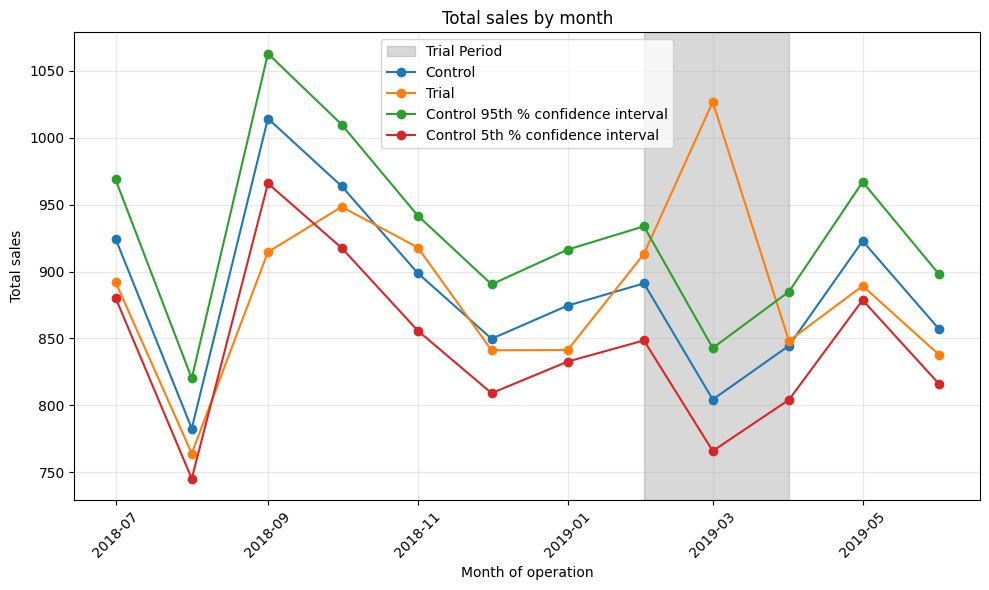

In [191]:
#Number of unique store types
store_types = trial_assessment[trial_assessment['STORE_TYPE'] != 'Other stores']['STORE_TYPE'].unique()

# Plot a graph showcasing these store types (Sales)
plt.figure(figsize=(10,6))

plt.axvspan(
    pd.to_datetime('2019-02-01'),
    pd.to_datetime('2019-04-01'),
    color='grey',
    alpha=0.3,  
    label='Trial Period'
)

for store_type in store_types:
    data = trial_assessment[trial_assessment['STORE_TYPE'] == store_type]
    plt.plot(
        data['TransactionMonth'],
        data['totSales'],
        label=store_type,
        marker='o'
    )

plt.title('Total sales by month')
plt.xlabel('Month of operation')
plt.ylabel('Total sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Compared to 77 and 233, the difference is not significant in total sales in the control and the trial store during the trial period. The total sales in 2019-02 and 2019-04 still lies in between the 5% and 95% confidence intervals, contrast to the other trial stores (77 and 88) with 2 months with sales lies outside the intervals

##### b. Scaled Customers

In [192]:
# Scaling no of customer pre trial stores (86 & 155)
scaling_factor_customer = pre_trial[pre_trial['STORE_NBR'] == trial_store]['totSales'].sum() / pre_trial[pre_trial['STORE_NBR'] == control_store]['totSales'].sum()
scaling_factor_customer

customers_over_time = measure_over_time.copy()

customers_over_time['scaledControlCustomers'] = customers_over_time.apply(
    lambda row: row['nCustomers'] * scaling_factor_customer 
    if row['STORE_NBR'] == control_store else np.nan,
    axis=1)

In [193]:
scaled_control_customers = customers_over_time[
    customers_over_time['STORE_NBR'] == control_store][['YEARMONTH', 'scaledControlCustomers']]

trial_store_customers = customers_over_time[
    customers_over_time['STORE_NBR'] == trial_store][['YEARMONTH', 'nCustomers']]

percent_diff_cus = pd.merge(scaled_control_customers,
                trial_store_customers,
                on=['YEARMONTH'])
percent_diff_cus['percentDiff'] = np.abs(percent_diff_cus['scaledControlCustomers'] - percent_diff_cus['nCustomers']) / percent_diff_cus['scaledControlCustomers']
percent_diff_cus

,YEARMONTH,scaledControlCustomers,nCustomers,percentDiff
0,201807,97.976580,99,0.010446
1,201808,88.275928,94,0.064843
2,201809,99.916710,103,0.030859
3,201810,104.767036,109,0.040404
4,201811,97.976580,100,0.020652
5,201812,94.096319,98,0.041486
6,201901,93.126254,94,0.009382
7,201902,92.156189,107,0.161072
8,201903,91.186124,115,0.261157
9,201904,96.036450,105,0.093335


In [194]:
# Calculate the percentage difference between scaled control and trial sales
pretrial_percent_diff_C = percent_diff_cus[percent_diff_cus['YEARMONTH'] < 201902]
std_dev_c = np.std(pretrial_percent_diff_C['percentDiff'])

degree_of_freedom = 7

# Change date format
percent_diff_cus['TransactionMonth'] = pd.to_datetime(
    (percent_diff_cus['YEARMONTH'] // 100).astype(str) + "-" + (percent_diff_cus['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

In [195]:
# Create a table for data during trial period
trial_data_customers = percent_diff_cus[
    (percent_diff_cus['YEARMONTH'] > 201901) &
    (percent_diff_cus['YEARMONTH'] < 201905)].copy()

trial_data_customers['tValue'] = (trial_data_customers['percentDiff'] - 0)/ std_dev_c
trial_data_customers

,YEARMONTH,scaledControlCustomers,nCustomers,percentDiff,TransactionMonth,tValue
7,201902,92.156189,107,0.161072,2019-02-01,8.808831
8,201903,91.186124,115,0.261157,2019-03-01,14.282318
9,201904,96.036450,105,0.093335,2019-04-01,5.104360


In [196]:
# Create a table for the total sales of trial and control store
past_customers = measure_over_time.copy()
past_customers['STORE_TYPE'] = past_customers['STORE_NBR'].apply(
    lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
)
past_customers = past_customers.groupby(['YEARMONTH', 'STORE_TYPE'])['nCustomers'].mean().reset_index()

past_customers['TransactionMonth'] = pd.to_datetime(
    (past_customers['YEARMONTH'] // 100).astype(str) + "-" + (past_customers['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

# Control store 95th percentile
past_customers_control_95 = past_customers[past_customers['STORE_TYPE'] == 'Control'].copy()
past_customers_control_95['nCustomers'] = past_customers_control_95['nCustomers'] * (1 + std_dev_c * 2)
past_customers_control_95['STORE_TYPE'] = 'Control 95th % confidence interval'

# Control store 5th percentile
past_customers_control_5 = past_customers[past_customers['STORE_TYPE'] == 'Control'].copy()
past_customers_control_5['nCustomers'] = past_customers_control_5['nCustomers'] * (1 - std_dev_c * 2)
past_customers_control_5['STORE_TYPE'] = 'Control 5th % confidence interval'

# Contains both percentiles
trial_assessment_cus = pd.concat([
    past_customers,
    past_customers_control_95,
    past_customers_control_5
])

#Number of unique store types
store_types = trial_assessment_cus[trial_assessment_cus['STORE_TYPE'] != 'Other stores']['STORE_TYPE'].unique()

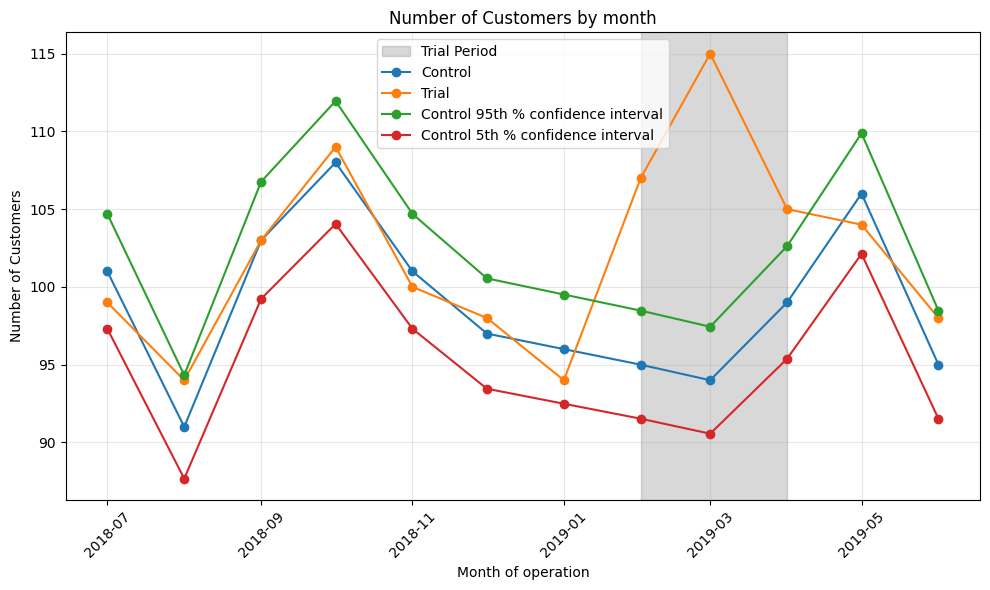

In [197]:
# Plot a graph showcasing these store types (Customers)
plt.figure(figsize=(10,6))

plt.axvspan(
    pd.to_datetime('2019-02-01'),
    pd.to_datetime('2019-04-01'),
    color='grey',
    alpha=0.3,  
    label='Trial Period'
)

for store_type in store_types:
    data = trial_assessment_cus[trial_assessment_cus['STORE_TYPE'] == store_type]
    plt.plot(
        data['TransactionMonth'],
        data['nCustomers'],
        label=store_type,
        marker='o'
    )

plt.title('Number of Customers by month')
plt.xlabel('Month of operation')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Strange enough, there is a significant difference in number of customers in the control and the trial store during the trial period, while the total sales is not.

### 3.3. Store 88

In [198]:
trial_store = 88

corr_sales = cal_correlation(pre_trial, 'totSales', trial_store)
corr_customers = cal_correlation(pre_trial, 'nCustomers', trial_store)

mag_sales = cal_magnitude_dist(pre_trial, 'totSales', trial_store)
mag_customers = cal_magnitude_dist(pre_trial, 'nCustomers', trial_store)

C:\Users\daoth\AppData\Local\Temp\ipykernel_15296\601032495.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  distance = pd.concat([distance, merged[['Store1','Store2','YEARMONTH','measure']]])


In [199]:
# Using correlation weights to find correlated stores
corr_weight = 0.5
score_sales = pd.merge(corr_sales,
                mag_sales,
                on=['Store1', 'Store2'])

score_sales['scoreSales'] = (score_sales['corr_measure'] * corr_weight +
                             score_sales['mag_measure'] * (1 - corr_weight))

score_customer = pd.merge(corr_customers,
                mag_customers,
                on=['Store1', 'Store2'])

score_customer['scoreCustomer'] = (score_customer['corr_measure'] * corr_weight +
                             score_customer['mag_measure'] * (1 - corr_weight))

score_control = pd.merge(score_sales,
                score_customer,
                on=['Store1', 'Store2'])
score_control

,Store1,Store2,corr_measure_x,mag_measure_x,scoreSales,corr_measure_y,mag_measure_y,scoreCustomer
0,88,1,0.813636,0.143453,0.478544,0.305334,0.353668,0.329501
1,88,2,-0.067927,0.116355,0.024214,-0.452379,0.302289,-0.075045
2,88,3,-0.507847,0.806064,0.149108,0.522884,0.849307,0.686095
3,88,4,-0.745566,0.901383,0.077909,-0.361503,0.93093,0.284713
4,88,5,0.190330,0.612614,0.401472,-0.025320,0.742127,0.358403
...,...,...,...,...,...,...,...,...
254,88,268,-0.021429,0.161613,0.070092,0.672672,0.337873,0.505273
255,88,269,-0.172578,0.712728,0.270075,-0.274781,0.852599,0.288909
256,88,270,-0.723272,0.717650,-0.002811,-0.103032,0.839071,0.36802
257,88,271,-0.103037,0.615957,0.256460,-0.018831,0.743121,0.362145


In [200]:
# Score control table
score_control = pd.merge(score_sales,
                score_customer,
                on=['Store1', 'Store2'])

score_control['finalControlScore'] = (score_control['scoreSales'] + score_control['scoreCustomer']) * 0.5

control_store = score_control[score_control['Store1'] == trial_store].sort_values(by='finalControlScore', ascending=False).iloc[0]['Store2']
control_store

237

So the most similar store to 86 is 237.

#### 3.3.1. Graphs for total Sales and Number of Customers before trial - *Store 88*

In [201]:
pre_trial['STORE_TYPE'] = pre_trial['STORE_NBR'].apply(
    lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
)

store_types = pre_trial['STORE_TYPE'].unique()

C:\Users\daoth\AppData\Local\Temp\ipykernel_15296\2315259260.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_trial['STORE_TYPE'] = pre_trial['STORE_NBR'].apply(


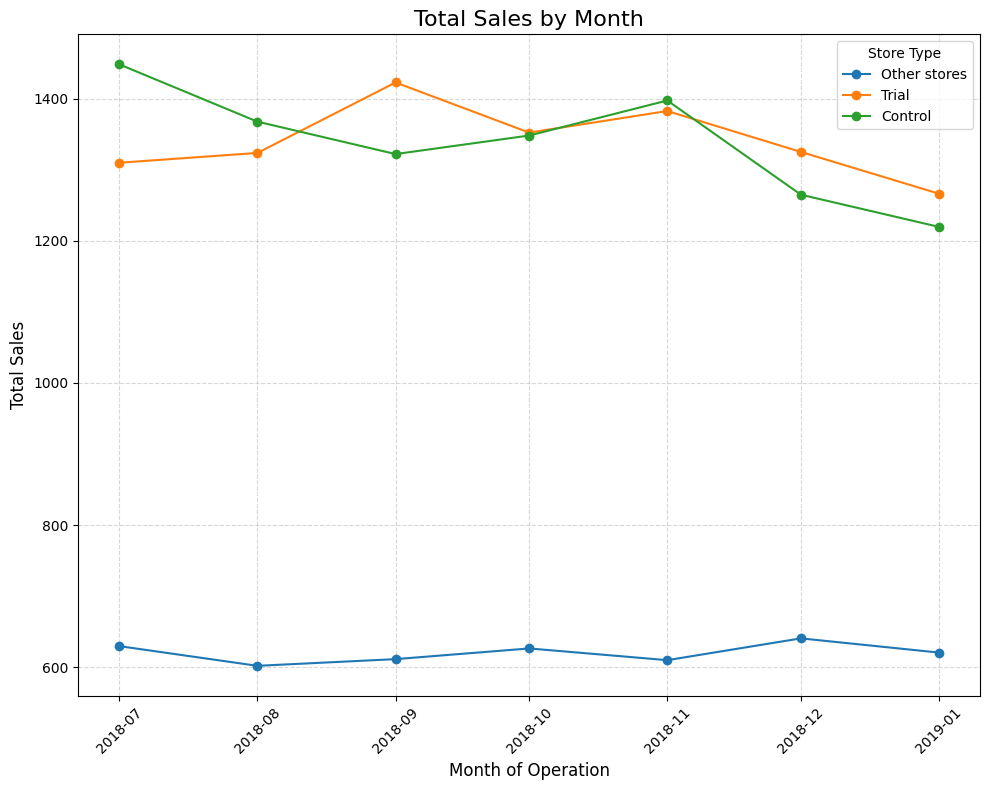

In [202]:
# Trends based on driver during the period before trial (Sales)
past_sales_trial = pre_trial.groupby(['YEARMONTH', 'STORE_TYPE'])['totSales'].mean().reset_index()

past_sales_trial['TransactionMonth'] = pd.to_datetime(
    (past_sales_trial['YEARMONTH'] // 100).astype(str) + "-" + (past_sales_trial['YEARMONTH'] % 100).astype(str),
    format="%Y-%m"
)

plt.figure(figsize=(10, 8))

for store_type in store_types:
    temp_data = past_sales_trial[past_sales_trial['STORE_TYPE'] == store_type]
    plt.plot(
        temp_data['TransactionMonth'],
        temp_data['totSales'],
        marker='o',
        label=store_type
    )

plt.title("Total Sales by Month", fontsize=16)
plt.xlabel("Month of Operation", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.legend(title="Store Type")
plt.xticks(rotation=45)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

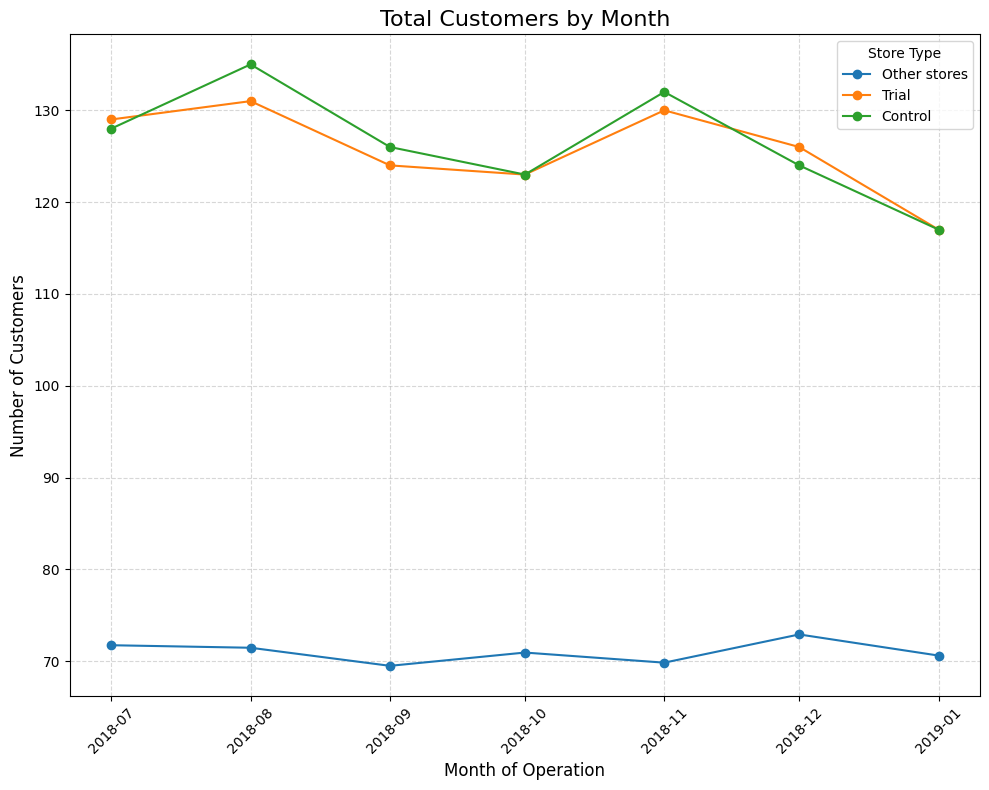

In [203]:
# Trends based on driver during the period before trial (Customer)
past_customers = pre_trial.groupby(['YEARMONTH', 'STORE_TYPE'])['nCustomers'].mean().reset_index()

past_customers['TransactionMonth'] = pd.to_datetime(
    (past_customers['YEARMONTH'] // 100).astype(str) + "-" + (past_customers['YEARMONTH'] % 100).astype(str),
    format="%Y-%m"
)

plt.figure(figsize=(10, 8))

for store_type in store_types:
    temp_data = past_customers[past_customers['STORE_TYPE'] == store_type]
    plt.plot(
        temp_data['TransactionMonth'],
        temp_data['nCustomers'],
        marker='o',
        label=store_type
    )

plt.title("Total Customers by Month", fontsize=16)
plt.xlabel("Month of Operation", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title="Store Type")
plt.xticks(rotation=45)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

#### 3.3.2. Assessment of Trial - *Store 88*

##### a. Scaled Sales

In [204]:
# Scaling sales pre trial stores (88 & 237)
scaling_factor_sales = pre_trial[pre_trial['STORE_NBR'] == trial_store]['totSales'].sum() / pre_trial[pre_trial['STORE_NBR'] == control_store]['totSales'].sum()
scaling_factor_sales

sales_over_time = measure_over_time.copy()

sales_over_time['scaledControlSales'] = sales_over_time.apply(
    lambda row: row['totSales'] * scaling_factor_sales 
    if row['STORE_NBR'] == control_store else np.nan,
    axis=1)

In [205]:
# Apply scaling factor
scaled_control_sales = sales_over_time[
    sales_over_time['STORE_NBR'] == control_store][['YEARMONTH', 'scaledControlSales']]

trial_store_sales = sales_over_time[
    sales_over_time['STORE_NBR'] == trial_store][['YEARMONTH', 'totSales']]

percent_diff_sales = pd.merge(scaled_control_sales,
                trial_store_sales,
                on=['YEARMONTH'])
percent_diff_sales['percentDiff'] = np.abs(percent_diff_sales['scaledControlSales'] - percent_diff_sales['totSales']) / percent_diff_sales['scaledControlSales']
percent_diff_sales

,YEARMONTH,scaledControlSales,totSales,percentDiff
0,201807,1450.657086,1310.00,0.096961
1,201808,1369.931485,1323.80,0.033674
2,201809,1324.260425,1423.00,0.074562
3,201810,1350.401097,1352.40,0.001480
4,201811,1399.777923,1382.80,0.012129
5,201812,1266.971288,1325.20,0.045959
6,201901,1221.600696,1266.40,0.036673
7,201902,1406.989143,1370.20,0.026147
8,201903,1210.082775,1477.20,0.220743
9,201904,1206.477165,1439.40,0.193060


In [206]:
# Calculate the percentage difference between scaled control and trial sales
pretrial_percent_diff_S = percent_diff_sales[percent_diff_sales['YEARMONTH'] < 201902]
std_dev_s = np.std(pretrial_percent_diff_S['percentDiff'])

degree_of_freedom = 7

# Change date format
percent_diff_sales['TransactionMonth'] = pd.to_datetime(
    (percent_diff_sales['YEARMONTH'] // 100).astype(str) + "-" + (percent_diff_sales['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

# Create a table for data during trial period
trial_data = percent_diff_sales[
    (percent_diff_sales['YEARMONTH'] > 201901) &
    (percent_diff_sales['YEARMONTH'] < 201905)].copy()

trial_data['tValue'] = (trial_data['percentDiff'] - 0)/ std_dev_s
trial_data

,YEARMONTH,scaledControlSales,totSales,percentDiff,TransactionMonth,tValue
7,201902,1406.989143,1370.2,0.026147,2019-02-01,0.843868
8,201903,1210.082775,1477.2,0.220743,2019-03-01,7.124136
9,201904,1206.477165,1439.4,0.193060,2019-04-01,6.230721


In [207]:
# Create a table for the total sales of trial and control store
past_sales = measure_over_time.copy()
past_sales['STORE_TYPE'] = past_sales['STORE_NBR'].apply(
    lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
)
past_sales = past_sales.groupby(['YEARMONTH', 'STORE_TYPE'])['totSales'].mean().reset_index()

past_sales['TransactionMonth'] = pd.to_datetime(
    (past_sales['YEARMONTH'] // 100).astype(str) + "-" + (past_sales['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

In [208]:
# Control store 95th percentile
past_sales_control_95 = past_sales[past_sales['STORE_TYPE'] == 'Control'].copy()
past_sales_control_95['totSales'] = past_sales_control_95['totSales'] * (1 + std_dev_s * 2)
past_sales_control_95['STORE_TYPE'] = 'Control 95th % confidence interval'

# Control store 5th percentile
past_sales_control_5 = past_sales[past_sales['STORE_TYPE'] == 'Control'].copy()
past_sales_control_5['totSales'] = past_sales_control_5['totSales'] * (1 - std_dev_s * 2)
past_sales_control_5['STORE_TYPE'] = 'Control 5th % confidence interval'

# Contains both percentiles
trial_assessment = pd.concat([
    past_sales,
    past_sales_control_95,
    past_sales_control_5
])

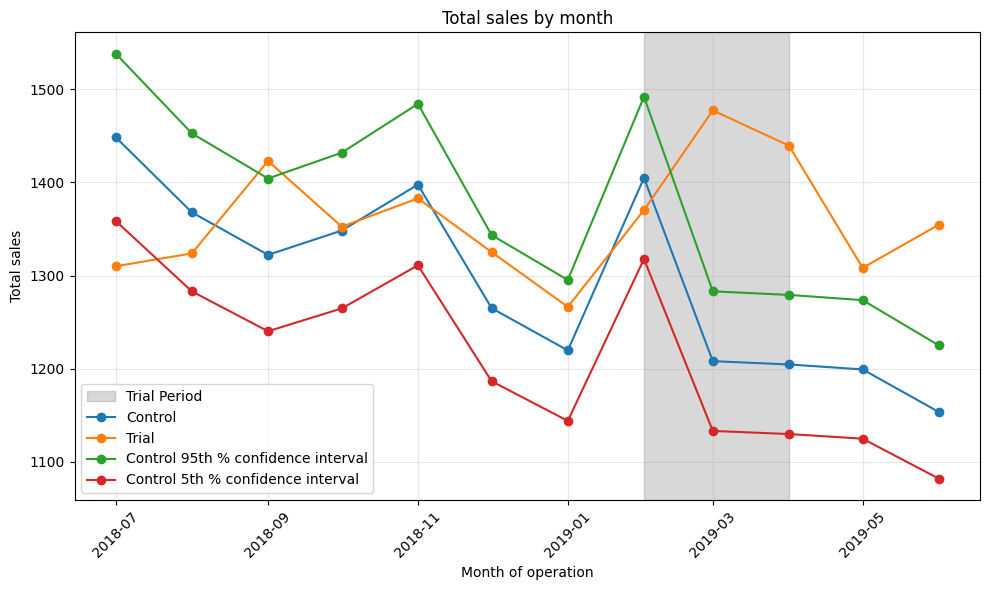

In [209]:
#Number of unique store types
store_types = trial_assessment[trial_assessment['STORE_TYPE'] != 'Other stores']['STORE_TYPE'].unique()

# Plot a graph showcasing these store types (Sales)
plt.figure(figsize=(10,6))

plt.axvspan(
    pd.to_datetime('2019-02-01'),
    pd.to_datetime('2019-04-01'),
    color='grey',
    alpha=0.3,  
    label='Trial Period'
)

for store_type in store_types:
    data = trial_assessment[trial_assessment['STORE_TYPE'] == store_type]
    plt.plot(
        data['TransactionMonth'],
        data['totSales'],
        label=store_type,
        marker='o'
    )

plt.title('Total sales by month')
plt.xlabel('Month of operation')
plt.ylabel('Total sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Similar to 77 and 233, there is a significant difference in total sales in the control and the trial store during the trial period

##### b. Scaled Customers

In [210]:
# Scaling no of customer pre trial stores (88 & 237)
scaling_factor_customer = pre_trial[pre_trial['STORE_NBR'] == trial_store]['totSales'].sum() / pre_trial[pre_trial['STORE_NBR'] == control_store]['totSales'].sum()
scaling_factor_customer

customers_over_time = measure_over_time.copy()

customers_over_time['scaledControlCustomers'] = customers_over_time.apply(
    lambda row: row['nCustomers'] * scaling_factor_customer 
    if row['STORE_NBR'] == control_store else np.nan,
    axis=1)

In [211]:
scaled_control_customers = customers_over_time[
    customers_over_time['STORE_NBR'] == control_store][['YEARMONTH', 'scaledControlCustomers']]

trial_store_customers = customers_over_time[
    customers_over_time['STORE_NBR'] == trial_store][['YEARMONTH', 'nCustomers']]

percent_diff_cus = pd.merge(scaled_control_customers,
                trial_store_customers,
                on=['YEARMONTH'])
percent_diff_cus['percentDiff'] = np.abs(percent_diff_cus['scaledControlCustomers'] - percent_diff_cus['nCustomers']) / percent_diff_cus['scaledControlCustomers']
percent_diff_cus

,YEARMONTH,scaledControlCustomers,nCustomers,percentDiff
0,201807,128.199466,129,0.006244
1,201808,135.210375,131,0.031139
2,201809,126.196350,124,0.017404
3,201810,123.191675,123,0.001556
4,201811,132.205700,130,0.016684
5,201812,124.193233,126,0.014548
6,201901,117.182325,117,0.001556
7,201902,126.196350,124,0.017404
8,201903,119.185441,134,0.124298
9,201904,120.187000,128,0.065007


In [212]:
# Calculate the percentage difference between scaled control and trial sales
pretrial_percent_diff_C = percent_diff_cus[percent_diff_cus['YEARMONTH'] < 201902]
std_dev_c = np.std(pretrial_percent_diff_C['percentDiff'])

degree_of_freedom = 7

# Change date format
percent_diff_cus['TransactionMonth'] = pd.to_datetime(
    (percent_diff_cus['YEARMONTH'] // 100).astype(str) + "-" + (percent_diff_cus['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

In [213]:
# Create a table for data during trial period
trial_data_customers = percent_diff_cus[
    (percent_diff_cus['YEARMONTH'] > 201901) &
    (percent_diff_cus['YEARMONTH'] < 201905)].copy()

trial_data_customers['tValue'] = (trial_data_customers['percentDiff'] - 0)/ std_dev_c
trial_data_customers

,YEARMONTH,scaledControlCustomers,nCustomers,percentDiff,TransactionMonth,tValue
7,201902,126.196350,124,0.017404,2019-02-01,1.777003
8,201903,119.185441,134,0.124298,2019-03-01,12.691091
9,201904,120.187000,128,0.065007,2019-04-01,6.637336


In [214]:
# Create a table for the total sales of trial and control store
past_customers = measure_over_time.copy()
past_customers['STORE_TYPE'] = past_customers['STORE_NBR'].apply(
    lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
)
past_customers = past_customers.groupby(['YEARMONTH', 'STORE_TYPE'])['nCustomers'].mean().reset_index()

past_customers['TransactionMonth'] = pd.to_datetime(
    (past_customers['YEARMONTH'] // 100).astype(str) + "-" + (past_customers['YEARMONTH'] % 100).astype(str) + "-" + "01" ,
    format='%Y-%m-%d'
)

# Control store 95th percentile
past_customers_control_95 = past_customers[past_customers['STORE_TYPE'] == 'Control'].copy()
past_customers_control_95['nCustomers'] = past_customers_control_95['nCustomers'] * (1 + std_dev_c * 2)
past_customers_control_95['STORE_TYPE'] = 'Control 95th % confidence interval'

# Control store 5th percentile
past_customers_control_5 = past_customers[past_customers['STORE_TYPE'] == 'Control'].copy()
past_customers_control_5['nCustomers'] = past_customers_control_5['nCustomers'] * (1 - std_dev_c * 2)
past_customers_control_5['STORE_TYPE'] = 'Control 5th % confidence interval'

# Contains both percentiles
trial_assessment_cus = pd.concat([
    past_customers,
    past_customers_control_95,
    past_customers_control_5
])

#Number of unique store types
store_types = trial_assessment_cus[trial_assessment_cus['STORE_TYPE'] != 'Other stores']['STORE_TYPE'].unique()

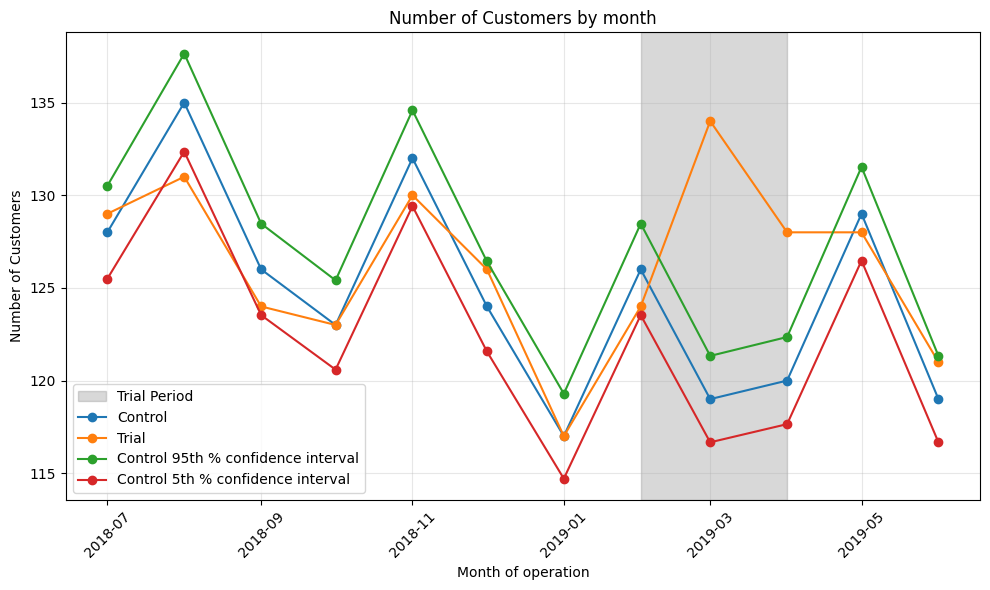

In [215]:
# Plot a graph showcasing these store types (Customers)
plt.figure(figsize=(10,6))

plt.axvspan(
    pd.to_datetime('2019-02-01'),
    pd.to_datetime('2019-04-01'),
    color='grey',
    alpha=0.3,  
    label='Trial Period'
)

for store_type in store_types:
    data = trial_assessment_cus[trial_assessment_cus['STORE_TYPE'] == store_type]
    plt.plot(
        data['TransactionMonth'],
        data['nCustomers'],
        label=store_type,
        marker='o'
    )

plt.title('Number of Customers by month')
plt.xlabel('Month of operation')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Similar to 77 and 233, there is a significant difference in number of customers in the control and the trial store during the trial period